# Wavenet 


Wavenet is a neural network which predicts audio sequence rather than character sequence 


In our previous neural probablistic architecture to predict the next sequence of character.

 
>architecture : https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

>   The problem with *neural probablistic architecture* is that it processes the context by concatenating the words vectors into a single fixed-size input. This make it hard to handle long-range dependencies because the model is limited to a fixed amount of context.

>As we increase the number of words in the history , the input size grows, which quickly makes the model very computationally expensive to train and run.


## Wavenet architecture

In wavenet architecture we operate it in a hierarrchical tree-like structure , the network can build up an understanding of th contect layer by layer rather than compressing all the information at once.

This hierarchical approach allows the model to connect early features with much later parts of the sequence effectively creating a much broader field of view for making predictions 

    


research paper : https://arxiv.org/pdf/1609.03499

In [21]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.__version__

'2.12.1+cu126'

In [22]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-07-06 21:04:24--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8001::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443... connected.
HTTP request sent, awaiting response... 416 Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [23]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [24]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [25]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [26]:
for x , y in zip(Xtr[:20] , Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [27]:
# Linear Layer


class Linear:

    def __init__(self , fan_in , fan_out , bias=True):
        self.weight = torch.randn((fan_in , fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self , x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [28]:
# BatchNorm1d Layer
class BatchNorm1d:
    def __init__(self , dim , eps=1e-5 , momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # parameters (trained with backprop)

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # buffer (trained with a running  momentum update)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)


    def __call__(self , x):
        # calculate the forward pass 

        if self.training:
            if x.ndim == 2:
                dim =0
            elif x.ndim ==3:
                dim = (0,1)
            xmean = x.mean(dim , keepdim=True)
            xvar = x.var(dim, keepdim=True )

        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta

        # update the buffers 
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)* self.running_mean  + self.momentum * xmean
                self.running_var = (1- self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma , self.beta] 

In [29]:
# Tanh layer

class Tanh:
    def __call__(self , x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [30]:
# embeddings and flatten layer

class Embedding:
    def __init__(self, num_embeddings , embeddings_dim):
        self.weight = torch.randn((num_embeddings , embeddings_dim))
    
    def __call__(self,IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0] , -1)
        return self.out

    def parameters(self):
        return []

class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n , C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

In [31]:
# Sequential 

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [32]:
g = torch.Generator().manual_seed(2147483647)

In [33]:
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # number of neurons in the hidden layer of mlp


model = Sequential([
    Embedding(vocab_size , n_embd),
    FlattenConsecutive(2), Linear(n_embd * 2 , n_hidden, bias=False) ,BatchNorm1d(n_hidden) ,  Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2 , n_hidden, bias=False) ,BatchNorm1d(n_hidden) ,  Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2 , n_hidden, bias=False) ,BatchNorm1d(n_hidden) ,  Tanh(),
    Linear (n_hidden , vocab_size),BatchNorm1d(vocab_size),
])


with torch.no_grad():
    # last layer : make less confident
    model.layers[-1].gamma *= 0.1

parameters = model.parameters()


print(sum(p.nelement() for p in parameters)) # number of parameters in total 

for p in parameters:
    p.requires_grad = True

76633


In [34]:
ix = torch.randint(0, Xtr.shape[0] , (4,))
Xb , Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  2, 18],
        [ 0,  0, 18, 15,  4,  7,  5, 18],
        [ 0,  0,  0,  0,  0,  0, 13,  1],
        [ 0,  0,  0,  0,  0,  0, 12, 15]])

In [35]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)
BatchNorm1d : (4, 27)


In [36]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,) , generator=g)
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    
    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits , Yb) # loss function
    

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        # break
    lossi.append(loss.log10().item())

    with torch.no_grad():
      ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])  

      0/ 200000: 3.2888
  10000/ 200000: 1.7949
  20000/ 200000: 1.8196
  30000/ 200000: 1.9119
  40000/ 200000: 2.0541
  50000/ 200000: 1.8685
  60000/ 200000: 2.1620
  70000/ 200000: 1.6339
  80000/ 200000: 1.7960
  90000/ 200000: 2.4211
 100000/ 200000: 2.2426
 110000/ 200000: 1.4045
 120000/ 200000: 1.6987
 130000/ 200000: 2.1169
 140000/ 200000: 1.8646
 150000/ 200000: 2.0836
 160000/ 200000: 1.8968
 170000/ 200000: 1.7403
 180000/ 200000: 2.4749
 190000/ 200000: 1.4205


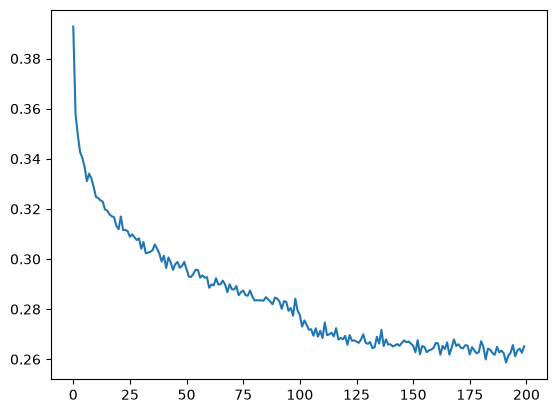

In [37]:
plt.plot(torch.tensor(lossi).view(-1 , 1000).mean(1))

In [38]:
# putting the layer in eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [39]:
# evaluate the loss
@torch.no_grad()
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte)
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(f"{split}: {loss.item():.4f}")

split_loss("train")
split_loss("dev")
split_loss("test")

train: 1.7813
dev: 1.9899
test: 1.9897


**Performace log**
* original (3 character context + 200 hidden  neurons , 12k parameters) : train : 2.0666 , val : 2.11
* context 3 - > 8 (22k params) , train : 1.953 , val : 2.033
* flat ->  hierarchical (22k params ) : train :1.9613 , val: 2.029
* fix bug in batchnorm : train:1.9309 , val: 2.284
* scale up the network: n_embd 24, n_hidden 128 (76K params): train:1.7813 , val:1.9897

In [40]:
# sample from the model

g = torch.Generator().manual_seed(2147483647 + 10)


for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # forward pass the neural net

        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carmaina.
jahlei.
kimri.
reity.
skarlete.
raheen.
delsyn.
jareei.
nellara.
chaily.
kaleigh.
hamsey.
jaquiln.
suline.
liven.
corter.
giaaruni.
jaceiline.
brendelo.
abette.
